# **ระบบพยากรณ์ความพึงพอใจของผู้โดยสารสายการบินด้วยเทคนิคการเรียนรู้ของเครื่อง**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn: Preprocessing & Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn: Models & Metrics
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# **โหลดข้อมูลและทำความสะอาด**

In [14]:
# โหลดไฟล์ข้อมูล (train.csv)
df = pd.read_csv('train.csv')

# ลบคอลัมน์ที่ไม่จำเป็น (ID และ Index)
# ข้อมูลไม่มีพลังในการทำนาย
# ป้องกันการเกิด Overfitting (โมเดลท่องจำ)
# ข้อมูลซ้ำซ้อนและเป็นขยะ
df = df.drop(['Unnamed: 0', 'id'], axis=1)

print(f"โหลดข้อมูลสำเร็จ! ขนาดข้อมูลปัจจุบัน: {df.shape}")
df.head()

โหลดข้อมูลสำเร็จ! ขนาดข้อมูลปัจจุบัน: (103904, 23)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# **ดูข้อมูลพื้นฐาน**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    1039

# **วิเคราะห์ข้อมูลเชิงสำรวจ (EDA)**

/tmp/ipykernel_194/1928406751.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='satisfaction', data=df, palette='viridis')


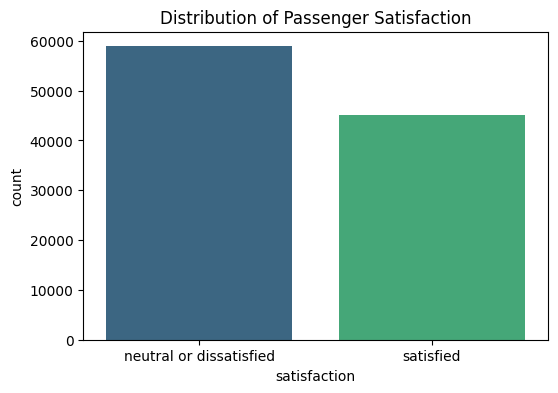


--- ตรวจสอบค่าว่าง (Missing Values) ---
Arrival Delay in Minutes    310
dtype: int64


In [15]:
# ดูความสมดุลของข้อมูล (คนพอใจ vs ไม่พอใจ)
plt.figure(figsize=(6, 4))
sns.countplot(x='satisfaction', data=df, palette='viridis')
plt.title('Distribution of Passenger Satisfaction')
plt.show()

# ตรวจสอบคอลัมน์ที่มีค่าว่าง
print("\n--- ตรวจสอบค่าว่าง (Missing Values) ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# **แยกข้อมูล Training และ Testing**

In [16]:
# แยก Features (X) และ Target (y)
X = df.drop('satisfaction', axis=1)

# แปลงเป้าหมายให้เป็นตัวเลข 0 และ 1
y = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# แบ่งข้อมูล 80% สำหรับเทรน และ 20% สำหรับทดสอบ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"แบ่งข้อมูลเรียบร้อย: Train {len(X_train)} ชุด, Test {len(X_test)} ชุด")

แบ่งข้อมูลเรียบร้อย: Train 83123 ชุด, Test 20781 ชุด


# **สร้าง Preprocessing Pipeline**

In [17]:
# ระบุกลุ่มคอลัมน์ตามประเภทข้อมูล
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# จัดการข้อมูลตัวเลข (เติมค่าว่างด้วย Median + ปรับสเกล)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# จัดการข้อมูลข้อความ (เติมค่าว่าง + ทำ One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# รวมชุดคำสั่ง Preprocessing ทั้งหมดเข้าด้วยกัน
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# **การจูนและเทรนโมเดล (Grid Search)**

In [18]:
# สร้าง Pipeline ที่รวม Preprocessor และโมเดลเข้าด้วยกัน
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# ตั้งค่าที่ต้องการจะจูน (ลองปรับเปลี่ยนค่าใน list ได้ครับ)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None]
}

# เริ่มค้นหาค่าที่ดีที่สุด (Grid Search)
print("--- กำลังเทรนและค้นหาค่าที่ดีที่สุด (อาจใช้เวลาสักครู่) ---")
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

--- กำลังเทรนและค้นหาค่าที่ดีที่สุด (อาจใช้เวลาสักครู่) ---
Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 200}


# **การประเมินผลเชิงลึก**

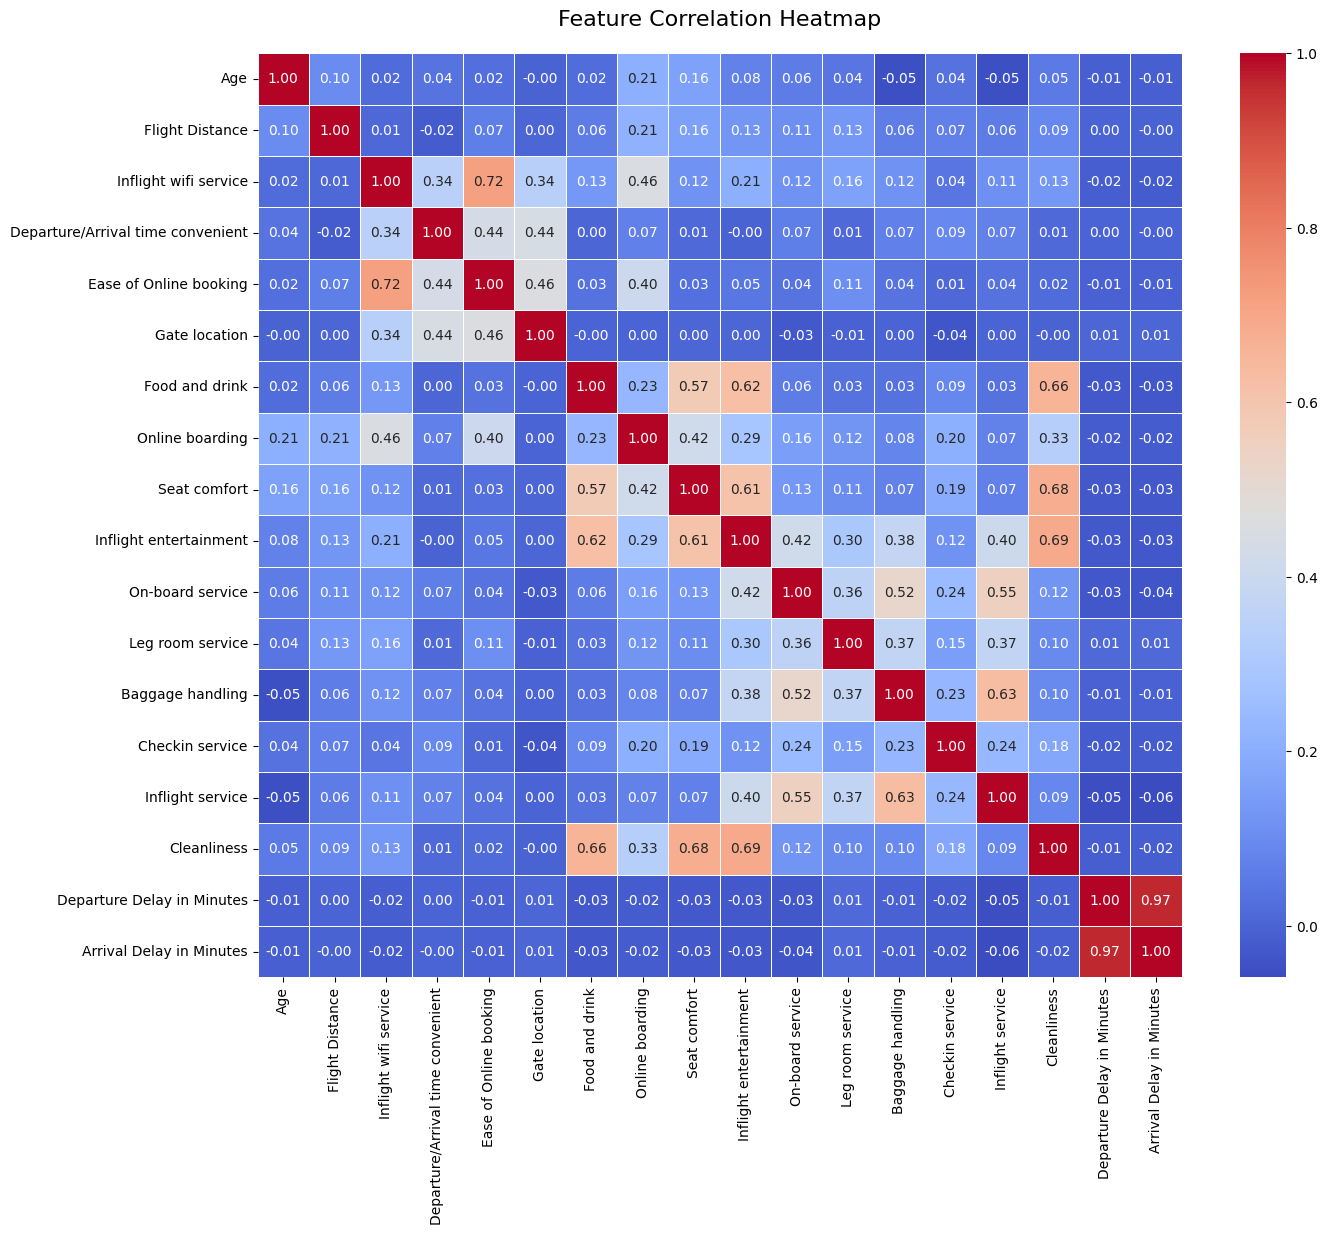

In [26]:
# 1. เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข
numeric_df = df.select_dtypes(include=[np.number])

# 2. คำนวณค่าความสัมพันธ์
corr_matrix = numeric_df.corr()

# 3. ตั้งค่าขนาดของกราฟ (ปรับให้ใหญ่พอที่จะเห็นตัวเลขชัดเจน)
plt.figure(figsize=(15, 12))

# 4. สร้าง Heatmap แบบเต็มผืน (Full Square)
# annot=True : แสดงตัวเลข
# fmt=".2f" : ทศนิยม 2 ตำแหน่ง
# cmap='coolwarm' : ใช้โทนสี น้ำเงิน-ขาว-แดง เหมือนในรูป
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5,
            square=True)

# 5. ตั้งชื่อกราฟ
plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.show()


--- รายงานผลลัพธ์ (Classification Report) ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11713
           1       0.98      0.94      0.96      9068

    accuracy                           0.96     20781
   macro avg       0.96      0.96      0.96     20781
weighted avg       0.96      0.96      0.96     20781



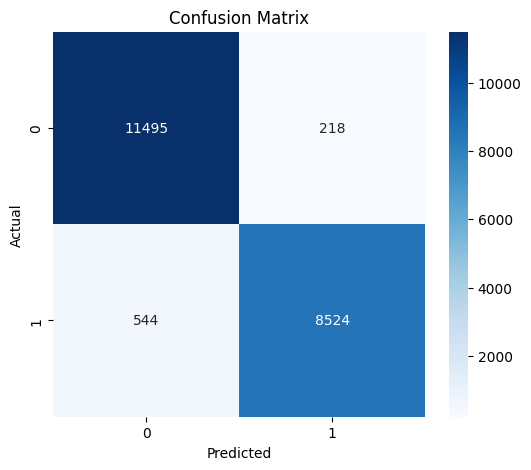

In [19]:
# ใช้โมเดลที่ดีที่สุดมาทายผลข้อมูล Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- รายงานผลลัพธ์ (Classification Report) ---")
print(classification_report(y_test, y_pred))

# แสดง Confusion Matrix ด้วย Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **บันทึกไฟล์โมเดล**

In [21]:
# บันทึกเป็นไฟล์ .pkl เพื่อนำไปใช้บนหน้าเว็บ Streamlit
joblib.dump(best_model, 'airline_satisfaction_pipeline.pkl', compress=3)

print("✅ บันทึกโมเดลสำเร็จ!")

✅ บันทึกโมเดลสำเร็จ!


# **โมเดลที่ใช้**
Random Forest Classifier (ตัวหลักที่ใช้ทำ Tuning)
XGBoost Classifier (ตัวเปรียบเทียบ)